In [1]:
import os
import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
dj.config.load("/home/sgao/source/spyglass/notebooks/dj_local_conf.json")  # load config for database connection info

import spyglass.common as sgc
import spyglass.position.v1 as sgp
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp import LFPOutput
import spyglass.lfp as sglfp
import spyglass.lfp as lfp
from spyglass.position import PositionOutput
from spyglass.lfp.v1.lfp_artifact import (
    LFPArtifactDetection,
    LFPArtifactDetectionParameters,
    LFPArtifactDetectionSelection,
)
import spyglass.ripple.v1 as sgrip
import spyglass.ripple.v1 as sgr

# ignore datajoint+jupyter async warnings
import warnings

warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-09-12 14:33:41,094][INFO]: DataJoint is configured from /home/sgao/source/spyglass/notebooks/dj_local_conf.json
[2026-09-12 14:33:41,626][INFO]: DataJoint 0.14.5 connected to sgao@lmf-db.cin.ucsf.edu:3306


In [5]:
import pynwb

nwb_file_name = "Marcus20260801_.nwb"

io = pynwb.NWBHDF5IO(
    "/stelmo/nwb/raw/Marcus20260801_.nwb",
    mode="r"
)

nwbf = io.read()

In [2]:
sgrip.RippleTimesV1() & {"nwb_file_name": 'Marcus20260801_.nwb'}

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,group_name,ripple_param_name a name for this set of parameters,pos_merge_id,analysis_file_name name of the file,ripple_times_object_id
008bb4aa-5cc4-3b06-3ecc-7b1185c057b7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,01_s1,1000,Ripple Detection Channels,default_trodes,f2e04a63-27bf-c5de-4d78-ed9eefa942df,Marcus20260801_QENAZUYNXH.nwb,14215ffb-0413-4997-83ca-986a7c01378e
008bb4aa-5cc4-3b06-3ecc-7b1185c057b7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,01_s1,1000,Ripple Detection Channels_16,default_trodes,f2e04a63-27bf-c5de-4d78-ed9eefa942df,Marcus20260801_6VQOUWWYUL.nwb,9f64a6e0-3824-4c4b-b41e-789bdba4f51f
12d3a444-fcb7-e9f0-be8d-a1a8129ff7d7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,05_s3,1000,Ripple Detection Channels,default_trodes,b22a600d-c286-d89f-e1e8-e6f22c87e3ff,Marcus20260801_QRSQNWW9UH.nwb,ddc5dd4d-6d95-485f-a871-8478d6d9ef17
12d3a444-fcb7-e9f0-be8d-a1a8129ff7d7,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,05_s3,1000,Ripple Detection Channels_16,default_trodes,b22a600d-c286-d89f-e1e8-e6f22c87e3ff,Marcus20260801_387AUAP0O4.nwb,6cdbf601-cd86-4b47-811b-aa6d2836bcaf
4d9dba5b-81d8-a28d-04ad-2503ac95db58,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,11_s6,1000,Ripple Detection Channels,default_trodes,7024f863-c0f7-abfc-b986-e95ceb19df0c,Marcus20260801_SZOA4Z22B9.nwb,f6891e9d-9e83-4b0e-a0ea-721676e4ab69
4d9dba5b-81d8-a28d-04ad-2503ac95db58,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,11_s6,1000,Ripple Detection Channels_16,default_trodes,7024f863-c0f7-abfc-b986-e95ceb19df0c,Marcus20260801_WQTYTFEVWG.nwb,5a964d9e-b482-4637-bb5b-5e2a962117e6
82600247-a4a6-d0e5-1930-4a343baf3649,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,03_s2,1000,Ripple Detection Channels,default_trodes,57c27e50-ebc4-d3d2-36e0-89ef8bf5d1e0,Marcus20260801_GZUILVW6JW.nwb,bef4ec68-f299-449b-9f31-ce107a577417
82600247-a4a6-d0e5-1930-4a343baf3649,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,03_s2,1000,Ripple Detection Channels_16,default_trodes,57c27e50-ebc4-d3d2-36e0-89ef8bf5d1e0,Marcus20260801_LJF6XLRWYX.nwb,0f2e80a0-b15b-4313-a1eb-e31dfc38ce23
c4d490cf-a82b-7ac9-99c9-78344fc1dce9,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,09_s5,1000,Ripple Detection Channels,default_trodes,a9be6fdd-747e-6d4a-7ef3-bf7cf2dacc4d,Marcus20260801_0X85Q5CIXQ.nwb,9ec0a26f-d452-4ced-9ccb-6eb4b403cc80
c4d490cf-a82b-7ac9-99c9-78344fc1dce9,Ripple 150-250 Hz,1000,Marcus20260801_.nwb,09_s5,1000,Ripple Detection Channels_16,default_trodes,a9be6fdd-747e-6d4a-7ef3-bf7cf2dacc4d,Marcus20260801_QYTRK625XF.nwb,80c19e9b-d32a-4a6f-80d1-eb3d2d37e5bb


In [6]:
nwb_file_name = "Marcus20260801_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

# NWB epoch indices (0-based)
session_epochs = {
    "01_s1": 0,
    "03_s2": 2,
    "05_s3": 4,
    "07_s4": 6,
    "09_s5": 8,
    "11_s6": 10,
}

# Get raw laser data
laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

results = []

for session in sleep_sessions:

    # ========================================================
    # OFFLINE — original 252-electrode detection
    # ========================================================

    ripple_252 = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "Ripple Detection Channels",
        }
    ).fetch1_dataframe()

    n_offline_252 = len(ripple_252)

    # ========================================================
    # OFFLINE — new 16-electrode detection
    # ========================================================

    ripple_16 = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "Ripple Detection Channels_16",
        }
    ).fetch1_dataframe()

    n_offline_16 = len(ripple_16)

    # ========================================================
    # ONLINE — laser trains
    # ========================================================

    epoch_number = session_epochs[session]

    epoch_start, epoch_stop, epoch_name = (
        nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
    )

    # Restrict raw laser data to this sleep session
    mask = (
        (laser_timestamps > epoch_start) &
        (laser_timestamps <= epoch_stop)
    )

    laser_session = laser_data[mask]
    laser_times_session = laser_timestamps[mask]

    # Raw laser signal is already binary.
    # Find OFF -> ON transitions = individual pulse starts.
    rising_edge_idx = np.where(
        np.diff(laser_session, prepend=0) == 1
    )[0]

    pulse_start_times = laser_times_session[rising_edge_idx]

    # 20 pulses = one online detection/train
    n_online = len(pulse_start_times) // 20

    # ========================================================
    # Save
    # ========================================================

    results.append({
        "session": session,
        "offline_252": n_offline_252,
        "offline_16": n_offline_16,
        "online": n_online,
    })


day1_counts = pd.DataFrame(results)

day1_counts

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
ndx-pose - cached version: 0.3.0, loaded version: 0.2.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 1/model
  w

,session,offline_252,offline_16,online
0,01_s1,913,958,0
1,03_s2,1216,1279,2169
2,05_s3,1462,1507,1180
3,07_s4,1793,1859,1364
4,09_s5,1737,1808,1782
5,11_s6,1547,1564,2186


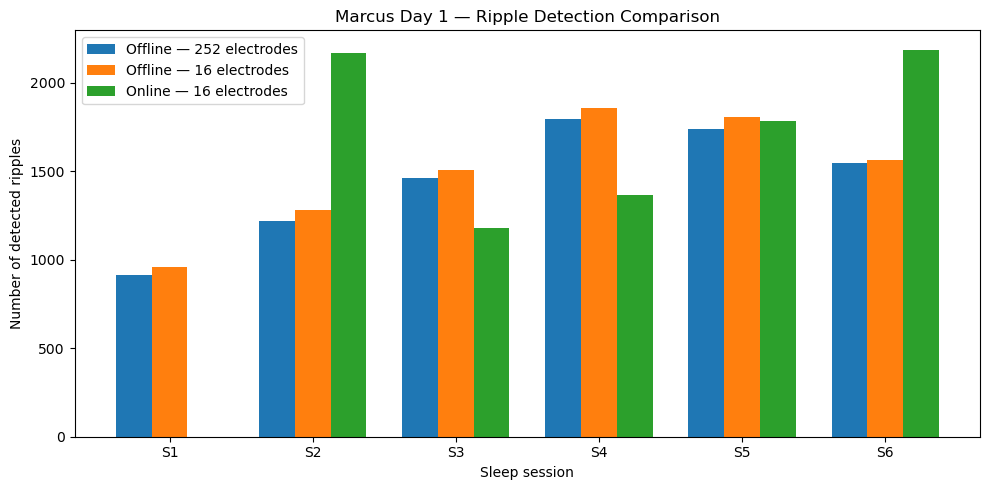

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(day1_counts))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    day1_counts["offline_252"],
    width,
    label="Offline — 252 electrodes"
)

plt.bar(
    x,
    day1_counts["offline_16"],
    width,
    label="Offline — 16 electrodes"
)

plt.bar(
    x + width,
    day1_counts["online"],
    width,
    label="Online — 16 electrodes"
)

plt.xticks(
    x,
    ["S1", "S2", "S3", "S4", "S5", "S6"]
)

plt.xlabel("Sleep session")
plt.ylabel("Number of detected ripples")
plt.title("Marcus Day 1 — Ripple Detection Comparison")

plt.legend()
plt.tight_layout()
plt.show()

In [8]:
results = []

for session in sleep_sessions:

    for group, label in [
        ("Ripple Detection Channels", "Offline 252"),
        ("Ripple Detection Channels_16", "Offline 16"),
    ]:

        ripples = (
            sgrip.RippleTimesV1()
            & {
                "nwb_file_name": "Marcus20260801_.nwb",
                "target_interval_list_name": session,
                "ripple_param_name": "default_trodes",
                "group_name": group,
            }
        ).fetch1_dataframe()

        results.append({
            "session": session,
            "detector": label,

            "mean_amplitude": ripples["max_zscore"].mean(),
            "median_amplitude": ripples["max_zscore"].median(),

            "mean_power": ripples["total_energy"].mean(),
            "median_power": ripples["total_energy"].median(),
        })

ripple_properties = pd.DataFrame(results)

ripple_properties

,session,detector,mean_amplitude,median_amplitude,mean_power,median_power
0,01_s1,Offline 252,4.209212,3.927032,0.436796,0.309086
1,01_s1,Offline 16,4.164020,3.977039,0.393202,0.301328
2,03_s2,Offline 252,4.547519,4.132720,0.748144,0.394111
3,03_s2,Offline 16,4.459895,4.062036,0.626115,0.362631
4,05_s3,Offline 252,4.462233,4.182286,0.738993,0.486252
5,05_s3,Offline 16,4.495390,4.282161,0.673372,0.458578
6,07_s4,Offline 252,4.318883,4.167837,0.766588,0.530114
7,07_s4,Offline 16,4.397484,4.244208,0.696220,0.486819
8,09_s5,Offline 252,4.369839,4.205140,0.724355,0.510930
9,09_s5,Offline 16,4.456488,4.300097,0.673765,0.488839


In [10]:
offline_252_all = []
offline_16_all = []

for session in sleep_sessions:

    # 252-electrode detector
    ripples_252 = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": "Marcus20260801_.nwb",
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "Ripple Detection Channels",
        }
    ).fetch1_dataframe()

    ripples_252 = ripples_252.copy()
    ripples_252["session"] = session
    offline_252_all.append(ripples_252)

    # 16-electrode detector
    ripples_16 = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": "Marcus20260801_.nwb",
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "Ripple Detection Channels_16",
        }
    ).fetch1_dataframe()

    ripples_16 = ripples_16.copy()
    ripples_16["session"] = session
    offline_16_all.append(ripples_16)


offline_252_all = pd.concat(
    offline_252_all,
    ignore_index=True
)

offline_16_all = pd.concat(
    offline_16_all,
    ignore_index=True
)

In [11]:
amp_252 = offline_252_all["max_zscore"].dropna()
amp_16 = offline_16_all["max_zscore"].dropna()

mean_252 = amp_252.mean()
median_252 = amp_252.median()

mean_16 = amp_16.mean()
median_16 = amp_16.median()

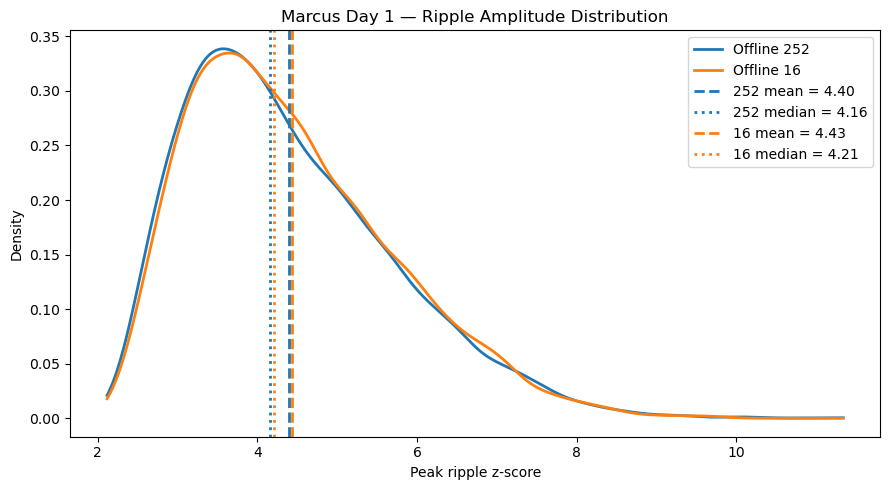

In [15]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

amp_252 = offline_252_all["max_zscore"].dropna().to_numpy()
amp_16 = offline_16_all["max_zscore"].dropna().to_numpy()

# KDE
kde_252 = gaussian_kde(amp_252)
kde_16 = gaussian_kde(amp_16)

x_min = min(amp_252.min(), amp_16.min())
x_max = max(amp_252.max(), amp_16.max())

x = np.linspace(x_min, x_max, 500)

# Mean and median
mean_252 = np.mean(amp_252)
median_252 = np.median(amp_252)

mean_16 = np.mean(amp_16)
median_16 = np.median(amp_16)

plt.figure(figsize=(9, 5))

# Distribution curves
line_252, = plt.plot(
    x,
    kde_252(x),
    linewidth=2,
    label="Offline 252"
)

line_16, = plt.plot(
    x,
    kde_16(x),
    linewidth=2,
    label="Offline 16"
)

# Get the colors automatically from the curves
color_252 = line_252.get_color()
color_16 = line_16.get_color()

# Offline 252
plt.axvline(
    mean_252,
    color=color_252,
    linestyle="--",
    linewidth=2,
    label=f"252 mean = {mean_252:.2f}"
)

plt.axvline(
    median_252,
    color=color_252,
    linestyle=":",
    linewidth=2,
    label=f"252 median = {median_252:.2f}"
)

# Offline 16
plt.axvline(
    mean_16,
    color=color_16,
    linestyle="--",
    linewidth=2,
    label=f"16 mean = {mean_16:.2f}"
)

plt.axvline(
    median_16,
    color=color_16,
    linestyle=":",
    linewidth=2,
    label=f"16 median = {median_16:.2f}"
)

plt.xlabel("Peak ripple z-score")
plt.ylabel("Density")
plt.title("Marcus Day 1 — Ripple Amplitude Distribution")

plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Marcus Day 1 — S5
# Online = 16-electrode detector
# Offline = 16-electrode detector
# ============================================================

nwb_file_name = "Marcus20260801_.nwb"
session = "09_s5"
epoch_number = 8

# ------------------------------------------------------------
# OFFLINE: 16-electrode ripple detections
# ------------------------------------------------------------

offline_s5 = (
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": nwb_file_name,
        "target_interval_list_name": session,
        "ripple_param_name": "default_trodes",
        "group_name": "Ripple Detection Channels_16",
    }
).fetch1_dataframe()

offline_start = offline_s5["start_time"].to_numpy()
offline_end = offline_s5["end_time"].to_numpy()

# ------------------------------------------------------------
# ONLINE: get laser pulses and group into 20-pulse trains
# ------------------------------------------------------------

epoch_start, epoch_stop, epoch_name = (
    nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
)

laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

mask = (
    (laser_timestamps > epoch_start) &
    (laser_timestamps <= epoch_stop)
)

laser_session = laser_data[mask]
laser_times_session = laser_timestamps[mask]

# Find individual laser pulse starts
rising_edge_idx = np.where(
    np.diff(laser_session, prepend=0) == 1
)[0]

pulse_start_times = laser_times_session[rising_edge_idx]

# Group 20 pulses = 1 online train
n_complete_trains = len(pulse_start_times) // 20

online_trains = pulse_start_times[
    :n_complete_trains * 20
].reshape(
    n_complete_trains,
    20
)

print("Offline SWRs:", len(offline_s5))
print("Online trains:", len(online_trains))


# ============================================================
# METHOD 1 — 10-ms window method
# First pulse must occur during ripple or <=10 ms after
# ============================================================

post_window = 0.010

first_pulses = online_trains[:, 0]

match_10ms = np.array([
    np.any(
        (t >= offline_start) &
        (t <= offline_end + post_window)
    )
    for t in first_pulses
])


# ============================================================
# METHOD 2 — Any of 20 pulses
# Any pulse must occur during offline ripple
# ============================================================

match_any20 = []

for train in online_trains:

    pulse_matches = (
        (train[:, None] >= offline_start[None, :]) &
        (train[:, None] <= offline_end[None, :])
    )

    match_any20.append(
        np.any(pulse_matches)
    )

match_any20 = np.array(match_any20)


# ============================================================
# RESULTS
# ============================================================

n_online = len(online_trains)

n_match_10ms = match_10ms.sum()
n_match_any20 = match_any20.sum()

pct_10ms = 100 * n_match_10ms / n_online
pct_any20 = 100 * n_match_any20 / n_online

print("\n10-ms window method")
print("Matched:", n_match_10ms)
print(f"Percent matched: {pct_10ms:.2f}%")

print("\nAny-of-20 method")
print("Matched:", n_match_any20)
print(f"Percent matched: {pct_any20:.2f}%")


# ============================================================
# HOW MANY EVENTS CHANGE CLASSIFICATION?
# ============================================================

both = match_10ms & match_any20
ten_ms_only = match_10ms & ~match_any20
any20_only = ~match_10ms & match_any20
neither = ~match_10ms & ~match_any20

print("\nClassification comparison")
print("Matched by both:", both.sum())
print("10-ms method only:", ten_ms_only.sum())
print("Any-of-20 method only:", any20_only.sum())
print("Matched by neither:", neither.sum())

Offline SWRs: 1808
Online trains: 1782

10-ms window method
Matched: 584
Percent matched: 32.77%

Any-of-20 method
Matched: 674
Percent matched: 37.82%

Classification comparison
Matched by both: 576
10-ms method only: 8
Any-of-20 method only: 98
Matched by neither: 1100


TP: at least one of the 20 pulses from an online train occurs during that offline SWR.

FN: no online pulse occurs during that offline SWR.

Latency for TP: time from the offline ripple start to the first online pulse that occurs inside that ripple.

In [21]:
# ============================================================
# S5 — Offline ripple perspective
# Any-of-20 matching method
# ============================================================

offline_start = offline_s5["start_time"].to_numpy()
offline_end = offline_s5["end_time"].to_numpy()

# Flatten all online pulse timestamps
all_online_pulses = online_trains.flatten()

tp = []
latencies = []

for start, end in zip(offline_start, offline_end):

    # Find all online pulses occurring inside this offline SWR
    pulses_inside = all_online_pulses[
        (all_online_pulses >= start) &
        (all_online_pulses <= end)
    ]

    if len(pulses_inside) > 0:

        # This offline ripple is a TP
        tp.append(True)

        # First pulse occurring during this ripple
        first_matching_pulse = pulses_inside.min()

        # Latency from ripple start
        latency = first_matching_pulse - start

        latencies.append(latency)

    else:

        # This offline ripple is a FN
        tp.append(False)

        # FN has no detection latency
        latencies.append(np.nan)


tp = np.array(tp)
latencies = np.array(latencies)

In [22]:
n_offline = len(offline_s5)

n_tp = tp.sum()
n_fn = (~tp).sum()

print("Total offline SWRs:", n_offline)
print("True positives:", n_tp)
print("False negatives:", n_fn)

print(
    f"Percent captured online: "
    f"{100 * n_tp / n_offline:.2f}%"
)

print(
    f"False-negative rate: "
    f"{100 * n_fn / n_offline:.2f}%"
)

Total offline SWRs: 1808
True positives: 727
False negatives: 1081
Percent captured online: 40.21%
False-negative rate: 59.79%


In [23]:
tp_latency_ms = latencies[tp] * 1000

print("TP latency (ms)")
print("Mean:", np.mean(tp_latency_ms))
print("Median:", np.median(tp_latency_ms))
print("Min:", np.min(tp_latency_ms))
print("Max:", np.max(tp_latency_ms))

print(
    "25th / 50th / 75th percentile:",
    np.percentile(tp_latency_ms, [25, 50, 75])
)

TP latency (ms)
Mean: 51.82909506387199
Median: 39.2003059387207
Min: 0.0
Max: 537.9049777984619
25th / 50th / 75th percentile: [10.13338566 39.20030594 76.70068741]


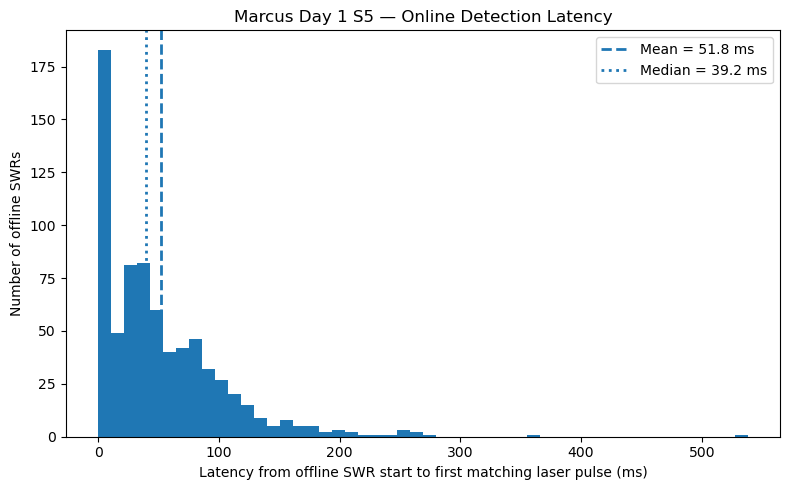

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    tp_latency_ms,
    bins=50
)

plt.axvline(
    np.mean(tp_latency_ms),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(tp_latency_ms):.1f} ms"
)

plt.axvline(
    np.median(tp_latency_ms),
    linestyle=":",
    linewidth=2,
    label=f"Median = {np.median(tp_latency_ms):.1f} ms"
)

plt.xlabel("Latency from offline SWR start to first matching laser pulse (ms)")
plt.ylabel("Number of offline SWRs")
plt.title("Marcus Day 1 S5 — Online Detection Latency")

plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# S5 — Find candidate FP online trains
# ============================================================

# online_trains = shape (number of trains, 20)
# offline_s5 = offline 16-electrode ripple dataframe

offline_start = offline_s5["start_time"].to_numpy()
offline_end = offline_s5["end_time"].to_numpy()

online_train_has_match = []

for train in online_trains:

    # Check all 20 pulses against all offline ripples
    pulse_matches = (
        (train[:, None] >= offline_start[None, :]) &
        (train[:, None] <= offline_end[None, :])
    )

    # True if at least one of the 20 pulses overlaps
    # at least one offline ripple
    online_train_has_match.append(
        np.any(pulse_matches)
    )

online_train_has_match = np.array(
    online_train_has_match
)

# Candidate FP trains
fp_trains_s5 = online_trains[
    ~online_train_has_match
]

print("Total online trains:", len(online_trains))
print("Matched trains:", online_train_has_match.sum())
print("Candidate FP trains:", len(fp_trains_s5))

Total online trains: 1782
Matched trains: 674
Candidate FP trains: 1108


In [29]:
fp_index = 0

fp_train = fp_trains_s5[fp_index]

print("FP first pulse:", fp_train[0])
print("FP last pulse:", fp_train[-1])
print(
    "Train duration:",
    (fp_train[-1] - fp_train[0]) * 1000,
    "ms"
)

FP first pulse: 1785620824.6487496
FP last pulse: 1785620824.7432837
Train duration: 94.53415870666504 ms


In [32]:
nwb_file_name = "Marcus20260801_.nwb"
session = "09_s5"

# Get the existing 150-250 Hz ripple-band LFP for S5
lfp_band_query = (
    lfp_analysis.LFPBandV1()
    & {
        "nwb_file_name": nwb_file_name,
        "target_interval_list_name": session,
        "filter_name": "Ripple 150-250 Hz",
    }
)

print("Number of matching LFPBand entries:", len(lfp_band_query))

lfp_band_key = lfp_band_query.fetch1("KEY")

print(lfp_band_key)

Number of matching LFPBand entries: 1
{'lfp_merge_id': UUID('c4d490cf-a82b-7ac9-99c9-78344fc1dce9'), 'filter_name': 'Ripple 150-250 Hz', 'filter_sampling_rate': 1000, 'nwb_file_name': 'Marcus20260801_.nwb', 'target_interval_list_name': '09_s5', 'lfp_band_sampling_rate': 1000}


[2026-09-12 15:25:44,843][WARNING]: Skipped checksum for file with hash: a864e6a6-b84b-2674-2a7c-35a08a6c8191, and path: /stelmo/nwb/analysis/Marcus20260801/Marcus20260801_0K0OT3M9YF.nwb
[2026-09-12 15:25:44,850][WARNING]: Skipped checksum for file with hash: a864e6a6-b84b-2674-2a7c-35a08a6c8191, and path: /stelmo/nwb/analysis/Marcus20260801/Marcus20260801_0K0OT3M9YF.nwb


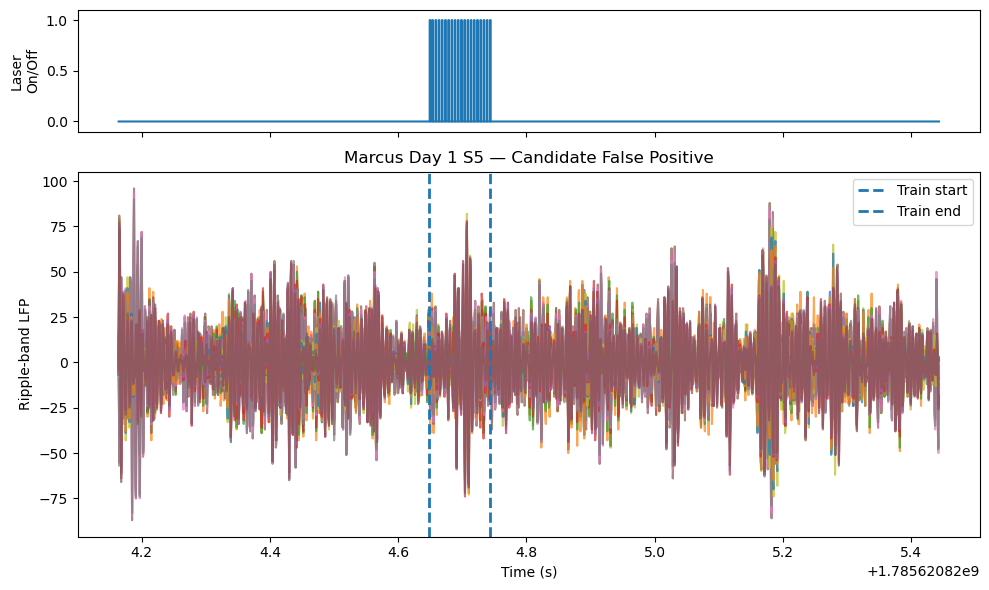

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Candidate FP
# ------------------------------------------------------------

fp_index = 0

fp_train = fp_trains_s5[fp_index]

train_start = fp_train[0]
train_end = fp_train[-1]

window = 0.7

# ------------------------------------------------------------
# Load S5 ripple-band data
# ------------------------------------------------------------

ripple_band_df = (
    lfp_analysis.LFPBandV1() & lfp_band_key
).fetch1_dataframe()

time_window = ripple_band_df.loc[
    train_start - window :
    train_end + window
]

# ------------------------------------------------------------
# Actual 16 electrodes used for ripple detection
# ------------------------------------------------------------

electrode_list = [
    16, 17, 18, 19,
    48, 49, 50, 51,
    404, 405, 406, 407,
    436, 437, 438, 439
]

# Get the electrode order used by this LFPBand
lfp_band_electrodes = (
    lfp_analysis.LFPBandSelection.LFPBandElectrode()
    & {
        "nwb_file_name": "Marcus20260801_.nwb",
        "target_interval_list_name": "09_s5",
        "filter_name": "Ripple 150-250 Hz",
    }
).fetch("electrode_id")

# Map actual electrode ID -> dataframe column position
electrode_to_column = {
    electrode_id: column
    for column, electrode_id in enumerate(lfp_band_electrodes)
}

# Find the dataframe columns corresponding to our 16 electrodes
plot_columns = [
    electrode_to_column[e]
    for e in electrode_list
]

time_window_16 = time_window.iloc[:, plot_columns]

# ------------------------------------------------------------
# Create binary laser trace for all 20 pulses
# ------------------------------------------------------------

binary_trace = np.zeros(len(time_window.index))

for ts in fp_train:

    idx = np.argmin(
        np.abs(time_window.index.values - ts)
    )

    binary_trace[idx] = 1

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# Top: laser
ax1.step(
    time_window.index,
    binary_trace,
    where="post"
)

ax1.set_ylabel("Laser\nOn/Off")
ax1.set_ylim(-0.1, 1.1)

# Bottom: 16 ripple-band electrodes
ax2.plot(
    time_window.index,
    time_window_16,
    alpha=0.7
)

# Mark online train start/end
ax2.axvline(
    train_start,
    linestyle="--",
    linewidth=2,
    label="Train start"
)

ax2.axvline(
    train_end,
    linestyle="--",
    linewidth=2,
    label="Train end"
)

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Ripple-band LFP")

ax2.set_title(
    "Marcus Day 1 S5 — Candidate False Positive"
)

ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

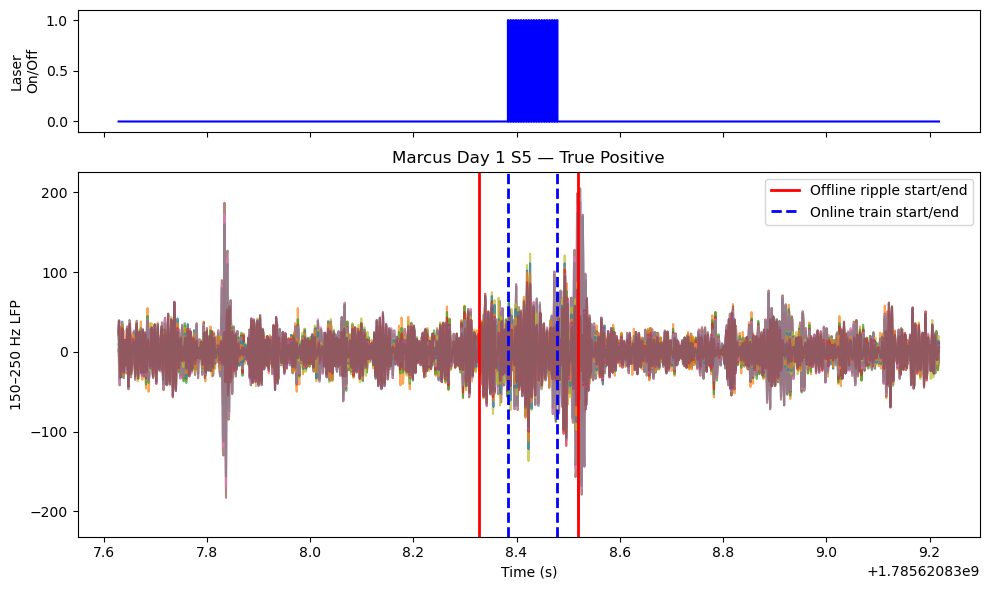

In [43]:
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# ------------------------------------------------------------
# Top: laser train
# ------------------------------------------------------------

ax1.step(
    time_window.index,
    binary_trace,
    where="post",
    color="blue"
)

ax1.set_ylabel("Laser\nOn/Off")
ax1.set_ylim(-0.1, 1.1)

# ------------------------------------------------------------
# Bottom: 16 ripple-band electrodes
# ------------------------------------------------------------

ax2.plot(
    time_window_16.index,
    time_window_16,
    alpha=0.7
)

# ------------------------------------------------------------
# Offline ripple boundaries — RED SOLID
# ------------------------------------------------------------

ax2.axvline(
    ripple_start,
    color="red",
    linestyle="-",
    linewidth=2,
    label="Offline ripple start/end"
)

ax2.axvline(
    ripple_end,
    color="red",
    linestyle="-",
    linewidth=2
)

# ------------------------------------------------------------
# Online train boundaries — BLUE DASHED
# ------------------------------------------------------------

ax2.axvline(
    train_start,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Online train start/end"
)

ax2.axvline(
    train_end,
    color="blue",
    linestyle="--",
    linewidth=2
)

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("150–250 Hz LFP")

ax2.set_title(
    "Marcus Day 1 S5 — True Positive"
)

ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [45]:
import numpy as np
import pandas as pd

# ============================================================
# S5 — classify every OFFLINE ripple as TP or FN
# ============================================================

offline_s5 = offline_s5.copy()

offline_start = offline_s5["start_time"].to_numpy()
offline_end = offline_s5["end_time"].to_numpy()

offline_captured = []

for start, end in zip(offline_start, offline_end):

    # Does ANY pulse from ANY online train fall inside this ripple?
    match = np.any(
        (online_trains >= start) &
        (online_trains <= end)
    )

    offline_captured.append(match)

offline_s5["online_captured"] = np.array(offline_captured)

# Duration
offline_s5["duration"] = (
    offline_s5["end_time"] -
    offline_s5["start_time"]
)

# Split into TP and FN
tp_ripples = offline_s5[
    offline_s5["online_captured"]
].copy()

fn_ripples = offline_s5[
    ~offline_s5["online_captured"]
].copy()

print("Total offline ripples:", len(offline_s5))
print("Captured online (TP):", len(tp_ripples))
print("Missed online (FN):", len(fn_ripples))
print(
    f"Offline capture rate: "
    f"{100 * len(tp_ripples) / len(offline_s5):.2f}%"
)

Total offline ripples: 1808
Captured online (TP): 727
Missed online (FN): 1081
Offline capture rate: 40.21%


In [46]:
print("AMPLITUDE — max_zscore")

print("\nTP:")
print("Mean:", tp_ripples["max_zscore"].mean())
print("Median:", tp_ripples["max_zscore"].median())

print("\nFN:")
print("Mean:", fn_ripples["max_zscore"].mean())
print("Median:", fn_ripples["max_zscore"].median())

AMPLITUDE — max_zscore

TP:
Mean: 4.843037121352632
Median: 4.796195704060331

FN:
Mean: 4.196523070242688
Median: 4.060812078797938


In [47]:
print("DURATION")

print("\nTP:")
print(
    "Mean:",
    tp_ripples["duration"].mean() * 1000,
    "ms"
)
print(
    "Median:",
    tp_ripples["duration"].median() * 1000,
    "ms"
)

print("\nFN:")
print(
    "Mean:",
    fn_ripples["duration"].mean() * 1000,
    "ms"
)
print(
    "Median:",
    fn_ripples["duration"].median() * 1000,
    "ms"
)

DURATION

TP:
Mean: 139.33142605641194 ms
Median: 119.00115013122559 ms

FN:
Mean: 103.78079476122718 ms
Median: 89.00070190429688 ms


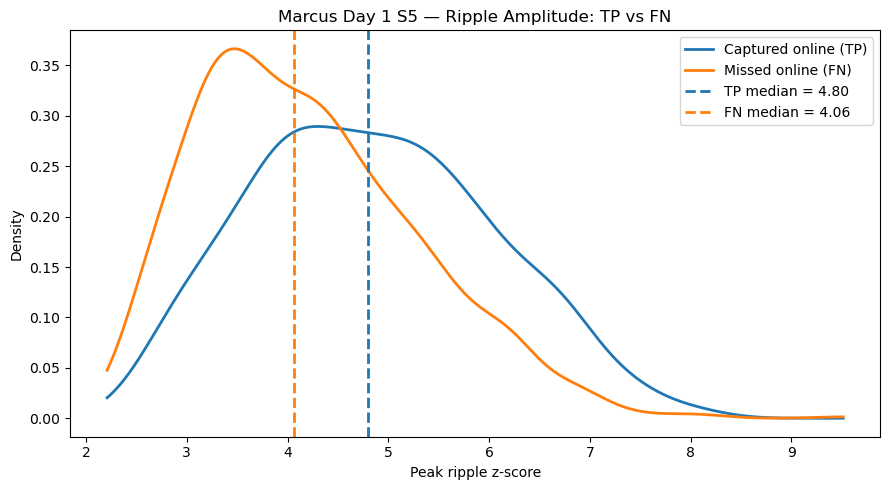

In [48]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

tp_amp = tp_ripples["max_zscore"].dropna().to_numpy()
fn_amp = fn_ripples["max_zscore"].dropna().to_numpy()

x = np.linspace(
    min(tp_amp.min(), fn_amp.min()),
    max(tp_amp.max(), fn_amp.max()),
    500
)

kde_tp = gaussian_kde(tp_amp)
kde_fn = gaussian_kde(fn_amp)

plt.figure(figsize=(9, 5))

line_tp, = plt.plot(
    x,
    kde_tp(x),
    linewidth=2,
    label="Captured online (TP)"
)

line_fn, = plt.plot(
    x,
    kde_fn(x),
    linewidth=2,
    label="Missed online (FN)"
)

# Medians
plt.axvline(
    np.median(tp_amp),
    color=line_tp.get_color(),
    linestyle="--",
    linewidth=2,
    label=f"TP median = {np.median(tp_amp):.2f}"
)

plt.axvline(
    np.median(fn_amp),
    color=line_fn.get_color(),
    linestyle="--",
    linewidth=2,
    label=f"FN median = {np.median(fn_amp):.2f}"
)

plt.xlabel("Peak ripple z-score")
plt.ylabel("Density")
plt.title("Marcus Day 1 S5 — Ripple Amplitude: TP vs FN")

plt.legend()
plt.tight_layout()
plt.show()

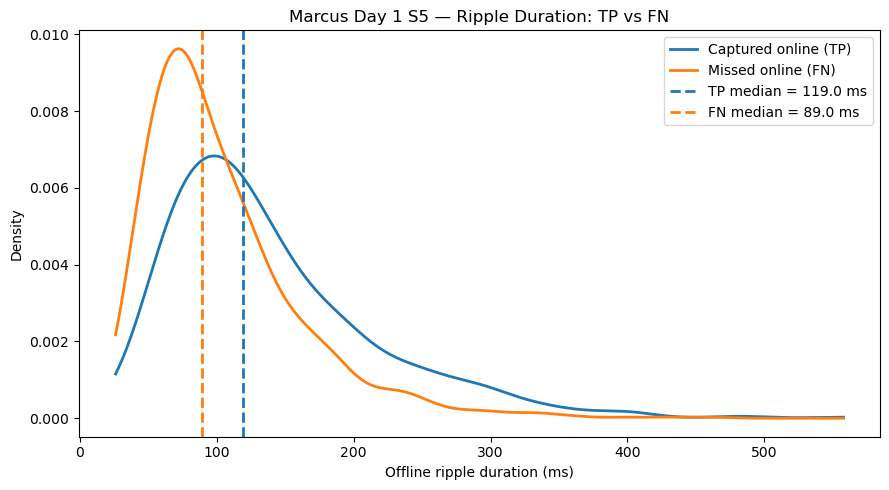

In [49]:
tp_duration = tp_ripples["duration"].to_numpy() * 1000
fn_duration = fn_ripples["duration"].to_numpy() * 1000

x = np.linspace(
    min(tp_duration.min(), fn_duration.min()),
    max(tp_duration.max(), fn_duration.max()),
    500
)

kde_tp = gaussian_kde(tp_duration)
kde_fn = gaussian_kde(fn_duration)

plt.figure(figsize=(9, 5))

line_tp, = plt.plot(
    x,
    kde_tp(x),
    linewidth=2,
    label="Captured online (TP)"
)

line_fn, = plt.plot(
    x,
    kde_fn(x),
    linewidth=2,
    label="Missed online (FN)"
)

plt.axvline(
    np.median(tp_duration),
    color=line_tp.get_color(),
    linestyle="--",
    linewidth=2,
    label=f"TP median = {np.median(tp_duration):.1f} ms"
)

plt.axvline(
    np.median(fn_duration),
    color=line_fn.get_color(),
    linestyle="--",
    linewidth=2,
    label=f"FN median = {np.median(fn_duration):.1f} ms"
)

plt.xlabel("Offline ripple duration (ms)")
plt.ylabel("Density")
plt.title("Marcus Day 1 S5 — Ripple Duration: TP vs FN")

plt.legend()
plt.tight_layout()
plt.show()

In [50]:
from scipy.stats import ttest_ind
import numpy as np

# ============================================================
# 1. RIPPLE AMPLITUDE — Welch's t-test
# ============================================================

tp_amp = tp_ripples["max_zscore"].dropna().to_numpy()
fn_amp = fn_ripples["max_zscore"].dropna().to_numpy()

t_amp, p_amp = ttest_ind(
    tp_amp,
    fn_amp,
    equal_var=False   # Welch's t-test
)

print("RIPPLE AMPLITUDE")
print("-----------------------------")
print("TP n:", len(tp_amp))
print("FN n:", len(fn_amp))

print(f"TP mean:   {np.mean(tp_amp):.3f}")
print(f"FN mean:   {np.mean(fn_amp):.3f}")

print(f"TP median: {np.median(tp_amp):.3f}")
print(f"FN median: {np.median(fn_amp):.3f}")

print(f"Welch's t = {t_amp:.3f}")
print(f"p = {p_amp:.3e}")


# ============================================================
# 2. RIPPLE DURATION — Welch's t-test
# ============================================================

tp_duration = (
    tp_ripples["duration"].dropna().to_numpy() * 1000
)

fn_duration = (
    fn_ripples["duration"].dropna().to_numpy() * 1000
)

t_duration, p_duration = ttest_ind(
    tp_duration,
    fn_duration,
    equal_var=False   # Welch's t-test
)

print("\nRIPPLE DURATION")
print("-----------------------------")
print("TP n:", len(tp_duration))
print("FN n:", len(fn_duration))

print(f"TP mean:   {np.mean(tp_duration):.1f} ms")
print(f"FN mean:   {np.mean(fn_duration):.1f} ms")

print(f"TP median: {np.median(tp_duration):.1f} ms")
print(f"FN median: {np.median(fn_duration):.1f} ms")

print(f"Welch's t = {t_duration:.3f}")
print(f"p = {p_duration:.3e}")

RIPPLE AMPLITUDE
-----------------------------
TP n: 727
FN n: 1081
TP mean:   4.843
FN mean:   4.197
TP median: 4.796
FN median: 4.061
Welch's t = 11.624
p = 6.132e-30

RIPPLE DURATION
-----------------------------
TP n: 727
FN n: 1081
TP mean:   139.3 ms
FN mean:   103.8 ms
TP median: 119.0 ms
FN median: 89.0 ms
Welch's t = 10.738
p = 8.516e-26


I just first record the TP and NP's max_z score and used welch's t-test to compare whether these means are significantly different. 

In [51]:
# ============================================================
# S5 — Latency analysis for captured offline ripples
# ============================================================

train_start_latencies = []
overlap_latencies = []

for start, end in zip(offline_start, offline_end):

    # --------------------------------------------------------
    # Find which online trains have ANY pulse inside this ripple
    # --------------------------------------------------------

    train_matches = np.any(
        (online_trains >= start) &
        (online_trains <= end),
        axis=1
    )

    matched_train_indices = np.where(train_matches)[0]

    # Only analyze captured offline ripples
    if len(matched_train_indices) > 0:

        # Use the first matching online train
        train = online_trains[matched_train_indices[0]]

        # ---------------------------------------------
        # 1. Actual online train start
        # ---------------------------------------------

        train_start = train[0]

        train_start_latency = (
            train_start - start
        ) * 1000

        train_start_latencies.append(
            train_start_latency
        )

        # ---------------------------------------------
        # 2. First pulse that actually overlaps ripple
        # ---------------------------------------------

        pulses_inside = train[
            (train >= start) &
            (train <= end)
        ]

        first_overlap = pulses_inside.min()

        overlap_latency = (
            first_overlap - start
        ) * 1000

        overlap_latencies.append(
            overlap_latency
        )


train_start_latencies = np.array(
    train_start_latencies
)

overlap_latencies = np.array(
    overlap_latencies
)

In [52]:
print("Number of captured offline ripples:",
      len(train_start_latencies))

print("\nTRAIN START latency")
print(
    "Mean:",
    np.mean(train_start_latencies),
    "ms"
)
print(
    "Median:",
    np.median(train_start_latencies),
    "ms"
)
print(
    "Min:",
    np.min(train_start_latencies),
    "ms"
)
print(
    "Max:",
    np.max(train_start_latencies),
    "ms"
)

print("\nFIRST OVERLAPPING PULSE latency")
print(
    "Mean:",
    np.mean(overlap_latencies),
    "ms"
)
print(
    "Median:",
    np.median(overlap_latencies),
    "ms"
)

Number of captured offline ripples: 727

TRAIN START latency
Mean: 38.29545200772922 ms
Median: 39.2003059387207 ms
Min: -94.00105476379395 ms
Max: 537.9049777984619 ms

FIRST OVERLAPPING PULSE latency
Mean: 51.82909506387199 ms
Median: 39.2003059387207 ms


In [53]:
tp_latency_results = []

for start, end in zip(offline_start, offline_end):

    train_matches = np.any(
        (online_trains >= start) &
        (online_trains <= end),
        axis=1
    )

    matched_indices = np.where(train_matches)[0]

    if len(matched_indices) > 0:

        train = online_trains[matched_indices[0]]

        train_start = train[0]

        pulses_inside = train[
            (train >= start) &
            (train <= end)
        ]

        first_overlap = pulses_inside.min()

        tp_latency_results.append({
            "ripple_duration_ms": (end - start) * 1000,
            "train_start_latency_ms": (train_start - start) * 1000,
            "first_overlap_latency_ms": (first_overlap - start) * 1000,
        })

tp_latency_df = pd.DataFrame(tp_latency_results)

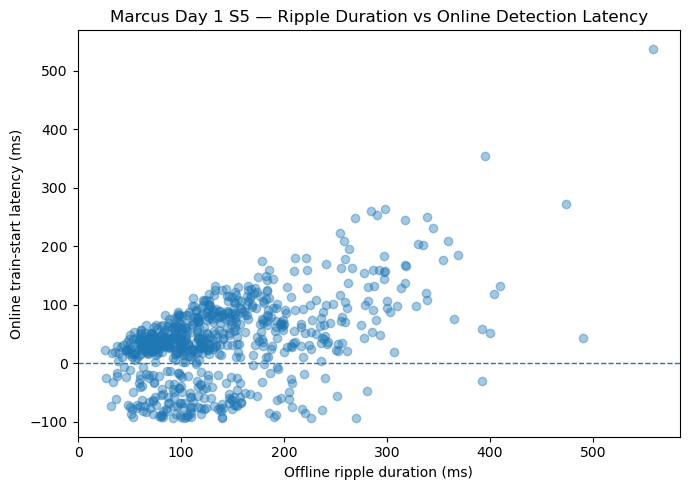

In [54]:
plt.figure(figsize=(7, 5))

plt.scatter(
    tp_latency_df["ripple_duration_ms"],
    tp_latency_df["train_start_latency_ms"],
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Offline ripple duration (ms)")
plt.ylabel("Online train-start latency (ms)")
plt.title("Marcus Day 1 S5 — Ripple Duration vs Online Detection Latency")

plt.tight_layout()
plt.show()

In [55]:
before = train_start_latencies < 0
after = train_start_latencies >= 0

print("Online train started BEFORE offline ripple:")
print(
    before.sum(),
    "/",
    len(train_start_latencies),
    f"({100 * before.mean():.1f}%)"
)

print("\nOnline train started AT/AFTER offline ripple:")
print(
    after.sum(),
    "/",
    len(train_start_latencies),
    f"({100 * after.mean():.1f}%)"
)

Online train started BEFORE offline ripple:
170 / 727 (23.4%)

Online train started AT/AFTER offline ripple:
557 / 727 (76.6%)
